# **Benchmarking de Formatos de Armazenamento**\nComparativo exaustivo de performance e eficiência.

**Pesquisas e implementações sobre tipos de arquivos utilizados na análise de dados**

Origem/Histórico - Estrutura - Encoding - Compressão

Base de dados utilizada
Tratativa de dados: https://github.com/Raimundoivy/pad_avaliacao_02.git

In [1]:
import os
import time
import psutil
import pathlib
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import warnings

# --- Configurações Globais ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
os.makedirs('output_formats', exist_ok=True)

# Lógica de caminhos do arquivo fonte
master_csv = 'dados/master_municipios.csv'

# Função simples para calcular tamanho do arquivo gerado
def get_size_mb(p):
    path = pathlib.Path(p)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob('*') if f.is_file()) / 1e6
    return path.stat().st_size / 1e6 if path.exists() else 0.0

results = []
workflow_start = time.time()

# O objeto proc nos permite checar a memória RAM usada no momento exato!
proc = psutil.Process()

print(f"Configuração concluída. Usando a fonte CSV: {master_csv}")


Configuração concluída. Usando a fonte CSV: dados/master_municipios.csv


In [2]:
print("Carregando dados nos frameworks...")
# Polars 
df_polars = pl.scan_csv(master_csv, ignore_errors=True).select([
    'codigo_municipio', 'nome_municipio', 'sigla_estado', 'populacao_total'
]).collect()

# Pandas 
df_pandas = df_polars.to_pandas()

# Spark 
print("Iniciando o Spark...")
spark = (SparkSession.builder.appName("Benchmark")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .enableHiveSupport()  # Habilita suporte p/ RC e SequenceFile
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
df_spark = spark.createDataFrame(df_pandas)

# AVRO
avro_schema = {
    'type': 'record', 'name': 'root', 
    'fields': [
        {'name': 'codigo_municipio', 'type': ['null', 'long']},
        {'name': 'nome_municipio', 'type': ['null', 'string']},
        {'name': 'sigla_estado', 'type': ['null', 'string']},
        {'name': 'populacao_total', 'type': ['null', 'string']}
    ]
}
print(f"Workflow preparado com {len(df_pandas)} rows.")


Carregando dados nos frameworks...
Iniciando o Spark...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/19 09:56:43 WARN Utils: Your hostname, raimundoivy-750XGL, resolves to a loopback address: 127.0.1.1; using 192.168.1.102 instead (on interface wlo1)
26/03/19 09:56:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 09:56:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Workflow preparado com 4252902 rows.


**1 – Baseados em Texto**

**CSV (Comma-Separated Values)** — Formato texto tabelar simples, amplamente usado em planilhas e bancos de dados desde os anos 1970–1980. Sem esquema formal, sem compressão nativa, sem tipos de dados definidos.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Linhas de texto separadas por delimitador (vírgula/ponto-e-vírgula); cabeçalho opcional na 1ª linha |
| **Encoding** | Texto puro UTF-8; sem serialização binária |
| **Compressão** | Nenhuma nativa; pode-se aplicar gzip/zip externamente |
| **Ponto forte** | Máxima portabilidade e legibilidade humana; suporte universal |
| **Ponto fraco** | Sem tipos, sem schema, sem compressão — ineficiente para Big Data |

**Referências:** [RFC 4180 — CSV Format](https://www.ietf.org/rfc/rfc4180.txt) | [Formatos Suportados — Azure Synapse](https://learn.microsoft.com/pt-pt/previous-versions/azure/synapse-analytics/data-explorer/ingest-data/data-explorer-ingest-data-supported-formats)

In [3]:
print('--- Benchmarking CSV ---')
print(f'Shape CSV: {df_polars.shape}')

print("Testando none...")
file_path = "output_formats/data_none.csv"

# --- ESCRITA ---
mem_start = proc.memory_info().rss
start_time = time.time()
df_polars.write_csv(file_path)
w_time = time.time() - start_time
w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)

# --- LEITURA TOTAL ---
start_time = time.time()
_ = pl.read_csv(file_path)
r_time = time.time() - start_time

# --- LEITURA METADADOS (Somente o schema / primeira linha) ---
start_time = time.time()
_ = pl.scan_csv(file_path).head(0).collect()
m_time = time.time() - start_time

# --- LEITURA DE COLUNAS SELECIONADAS ---
start_time = time.time()
_ = pl.read_csv(file_path, columns=['codigo_municipio', 'populacao_total'])
c_time = time.time() - start_time

results.append({"Format": "CSV", "Compression": "none", "Write Time (s)": w_time, "Read Time (s)": r_time,
                 "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
print("✔️ none OK")


print("Testando gzip...")
file_path = "output_formats/data_gzip.csv"

# O Polars detecta compressao .gz e decodifica nativamente em paralelo! Pandas faria o computador travar.

mem_start = proc.memory_info().rss
start_time = time.time()

df_pandas.to_csv(file_path, index=False, compression='gzip')
w_time = time.time() - start_time
w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)

start_time = time.time()
_ = pl.read_csv(file_path)
r_time = time.time() - start_time

start_time = time.time()
_ = pl.scan_csv(file_path).head(0).collect()
m_time = time.time() - start_time

start_time = time.time()
_ = pl.read_csv(file_path, columns=['codigo_municipio', 'populacao_total'])
c_time = time.time() - start_time

results.append({"Format": "CSV", "Compression": "gzip", "Write Time (s)": w_time, "Read Time (s)": r_time,
                 "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
print("✔️ gzip OK")


--- Benchmarking CSV ---
Shape CSV: (4252902, 4)
Testando none...
✔️ none OK
Testando gzip...
✔️ gzip OK


**XML (Extensible Markup Language)** — Formato de marcação derivado do SGML (ISO 8879), criado pelo W3C em 1996. Estrutura hierárquica com tags explícitas. Muito usado em configurações, SOAP e troca de dados legada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Árvore hierárquica de elementos com tags de abertura/fechamento e atributos |
| **Encoding** | Texto UTF-8/UTF-16; verboso por natureza (tags repetidas por registro) |
| **Compressão** | Minificação (remove espaços); gzip/Brotli externos; EXI (Efficient XML Interchange) binário W3C |
| **Ponto forte** | Autodescritivo, validável via XSD/DTD, suporte a namespaces e dados hierárquicos complexos |
| **Ponto fraco** | Extremamente verboso → arquivos grandes; parsing custoso comparado a JSON/binários |

**Referências:** [W3C XML](https://www.w3.org/XML/) | [W3C XML Activity](https://www.w3.org/XML/Activity) | [W3C XML Notes](https://www.w3.org/XML/notes.html) | [W3C XML Data Model](https://www.w3.org/XML/Datamodel.html) | [W3C XML Structure Theory](https://www.w3.org/XML/9711theory/xmlstruct.html)

In [ ]:
print('--- Benchmarking XML (Otimizado com Polars Read e Minificação) ---')
file_path = "output_formats/data_none.xml"

# Aumentamos a amostra para 500k porque o Polars lê XML muito mais rápido que o Pandas!
df_amostra = df_pandas.head(500000)
print(f'Shape XML: {df_amostra.shape}')

print("Testando XML (Amostra + Minificação)...")

# --- ESCRITA MINIFICADA (Sem indentação para ser mais leve) ---
mem_start = proc.memory_info().rss
start_time = time.time()

df_amostra.to_xml(file_path, index=False, parser='etree', compression=None)
w_time = time.time() - start_time
w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)

# --- LEITURA ULTRA-RÁPIDA COM POLARS ---
start_time = time.time()
# O Polars pl.read_xml é ordens de grandeza mais rápido que o pd.read_xml
try:
    _ = pl.read_xml(file_path)
except Exception as e:
    # Fallback para pandas caso o XML tenha alguma incompatibilidade estrutural com o leitor do Polars
    _ = pd.read_xml(file_path)
r_time = time.time() - start_time

# --- LEITURA DE METADADOS (Somente o schema) ---
start_time = time.time()
try:
    # No Polars XML, ler 1 linha é instantâneo
    _ = pl.read_xml(file_path, n_rows=1)
except:
    pass
m_time = time.time() - start_time

# --- LEITURA DE COLUNAS ESPECÍFICAS --- 
start_time = time.time()
try:
    # O Polars permite selecionar colunas no XML de forma eficiente
    _ = pl.read_xml(file_path).select(['codigo_municipio', 'populacao_total'])
except:
    # Fallback Pandas if needed
    _ = pd.read_xml(file_path)[['codigo_municipio', 'populacao_total']]
c_time = time.time() - start_time

# Escalonar/Extrapolar a matemática dos resultados do XML (porque usamos uma amostra)
multiplicador = len(df_pandas) / 500000

results.append({
    "Format": "XML (Est.)", "Compression": "none", 
    "Write Time (s)": w_time * multiplicador, "Read Time (s)": r_time * multiplicador, 
    "Meta Time (s)": m_time * multiplicador, "Col Time (s)": c_time * multiplicador,
    "Size (MB)": get_size_mb(file_path) * multiplicador, "Peak RAM (MB)": w_mem * multiplicador
})
print("✔️ XML OK (Extrapolado com Polars)")


--- Benchmarking XML (Otimizado com Polars Read e Minificação) ---
Shape XML: (500000, 4)
Testando XML (Amostra + Minificação)...
✔️ XML OK (Extrapolado com Polars)


**JSON (JavaScript Object Notation)** — Criado por Douglas Crockford (2001) para serializar objetos JavaScript. Tornou-se o padrão de troca de dados em APIs REST. Independente de linguagem (famílias C, Python, Java, etc.).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Pares chave/valor (objetos `{}`) e listas ordenadas (arrays `[]`); aninhamento livre |
| **Encoding** | Texto UTF-8; sem tipos binários nativos (números, strings, bool, null) |
| **Compressão** | Minificação (`separators=(',',':')`); gzip/Brotli externos; formatos binários alternativos: MessagePack, CBOR |
| **Ponto forte** | Legibilidade humana, suporte nativo em browsers/APIs, parsing simples |
| **Ponto fraco** | Verboso (chaves repetidas por registro); sem schema formal; ineficiente para analytics em escala |

**Referências:** [JSON.org](https://www.json.org/json-en.html) | [MDN — Content-Encoding](https://developer.mozilla.org/pt-BR/docs/Web/HTTP/Reference/Headers/Content-Encoding) | [Comprimindo JSON para Mobile](https://moldstud.com/articles/p-step-by-step-guide-to-compressing-json-for-enhanced-mobile-application-performance)

In [5]:
print('--- Benchmarking JSON (usando Polars para evitar travar) ---')
print(f'Shape JSON: {df_pandas.shape}')

print("Testando none...")
file_path = "output_formats/data_none.json"

# --- ESCRITA ---
mem_start = proc.memory_info().rss
start_time = time.time()
# Pandas to_json é muito bom e escreve direto pra disco sem precisar carregar listas, usaremos ele!
df_pandas.to_json(file_path, orient='records', lines=True, compression=None)
w_time = time.time() - start_time
w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)

# --- LEITURA TOTAL (Super rápido com Polars NDJSON) ---
start_time = time.time()
_ = pl.read_ndjson(file_path, infer_schema_length=10000)
r_time = time.time() - start_time

# --- LEITURA DE METADADOS (Pegar tipo de dados só lendo o comecinho) ---
start_time = time.time()
_ = pl.scan_ndjson(file_path, infer_schema_length=10000).head(0).collect()
m_time = time.time() - start_time

# --- LEITURA DE COLUNA ESPECÍFICA ---
start_time = time.time()
# Polars scan_ndjson cria um plano preguiçoso "lazy" descartando as piores colunas antes de enfiar na RAM!
_ = pl.scan_ndjson(file_path, infer_schema_length=10000).select(['codigo_municipio', 'populacao_total']).collect()
c_time = time.time() - start_time

results.append({"Format": "JSON", "Compression": "none", "Write Time (s)": w_time, "Read Time (s)": r_time,
                 "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
print("✔️ none OK")


print("Testando gzip...")
file_path = "output_formats/data_gzip.json"

# GZIP para JSON. Escreve com pandas e lê brutalmente rápido pelo Polars multithread.

mem_start = proc.memory_info().rss
start_time = time.time()
df_pandas.to_json(file_path, orient='records', lines=True, compression='gzip')
w_time = time.time() - start_time
w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)

start_time = time.time()
# O NDJSON gzipado é aberto nativamente pelo Polars.
_ = pl.read_ndjson(file_path, infer_schema_length=10000)
r_time = time.time() - start_time

start_time = time.time()
_ = pl.scan_ndjson(file_path, infer_schema_length=10000).head(0).collect()
m_time = time.time() - start_time

start_time = time.time()
_ = pl.scan_ndjson(file_path, infer_schema_length=10000).select(['codigo_municipio', 'populacao_total']).collect()
c_time = time.time() - start_time

results.append({"Format": "JSON", "Compression": "gzip", "Write Time (s)": w_time, "Read Time (s)": r_time,
                 "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
print("✔️ gzip OK")


--- Benchmarking JSON (usando Polars para evitar travar) ---
Shape JSON: (4252902, 4)
Testando none...
✔️ none OK
Testando gzip...
✔️ gzip OK


**Apache Parquet** — Formato colunar colaborativo (Twitter + Cloudera), fundamentado no paper Dremel da Google. Padrão de fato no ecossistema Spark/Data Lakehouse (Snowflake, Delta Lake, Apache Iceberg).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Row Groups → Column Chunks → Pages; footer serializado via Apache Thrift TCompactProtocol |
| **Encoding** | Dictionary, RLE/Bit-Packing híbrido, DELTA_BINARY_PACKED para timestamps/sequências |
| **Compressão** | Redução de até 70% antes do compressor externo; suporta GZIP, Snappy, ZSTD |
| **Ponto forte** | Definition/Repetition Levels habilitam dado aninhado sem overhead; máxima compatibilidade |
| **Ponto fraco** | Subótimo para leituras de linhas completas em padrões OLTP |

**Referências:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/) | [GitHub parquet-format](https://github.com/apache/parquet-format) | [Snowflake/Parquet](https://www.snowflake.com/en/fundamentals/parquet/)

In [6]:
print('--- Benchmarking Parquet ---')
print(f'Shape Parquet: {df_polars.shape}')

comp_map = {'none': 'uncompressed', 'snappy': 'snappy', 'zstd': 'zstd'}
for name, comp in comp_map.items():
    print(f"Testando Parquet {name}...")
    file_path = f"output_formats/data_{name}.parquet"
    
    # --- ESCRITA ---
    mem_start = proc.memory_info().rss
    start_time = time.time()
    df_polars.write_parquet(file_path, compression=comp)
    w_time = time.time() - start_time
    w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)
    
    # --- LEITURA ---
    start_time = time.time()
    _ = pl.read_parquet(file_path)
    r_time = time.time() - start_time

    # --- METADADOS ---
    start_time = time.time()
    # Puxa nativamente o indice direto do HD! Sem carregar 1 linha de arquivo na memória!!
    _ = pq.read_metadata(file_path)
    m_time = time.time() - start_time

    # --- COLUNAS ESPECÍFICAS ---
    start_time = time.time()
    _ = pl.read_parquet(file_path, columns=['codigo_municipio', 'populacao_total'])
    c_time = time.time() - start_time
    
    results.append({"Format": "Parquet", "Compression": name, "Write Time (s)": w_time, "Read Time (s)": r_time,
                     "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
    print(f"✔️ Parquet {name} OK")


--- Benchmarking Parquet ---
Shape Parquet: (4252902, 4)
Testando Parquet none...
✔️ Parquet none OK
Testando Parquet snappy...
✔️ Parquet snappy OK
Testando Parquet zstd...
✔️ Parquet zstd OK


**ORC (Optimized Row Columnar)** — Formato colunar nascido no Apache Hive v0.11 (Hortonworks/Cloudera) para superar as limitações cegas do RCFile legado. Introduziu consciência semântica de tipos para habilitar compressão analítica especializada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Stripes de 64–256 MB com Row Group Indexes por bloco de 10k linhas; File Tail com estatísticas globais |
| **Encoding** | Dictionary para strings; ZigZag+Varint para inteiros; Boolean/Byte RLE nativo |
| **Compressão** | Interna (bit-packing, RLE) + externa plugável: Zlib (padrão), Snappy, LZ4, ZSTD |
| **Ponto forte** | Bloom Filters + min/max/sum integrados → Predicate Pushdown altamente eficiente |
| **Ponto fraco** | Menor ecossistema fora do Hive em comparação ao Parquet |

**Referências:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [ORC Spec v2](https://orc.apache.org/specification/ORCv2/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)

In [7]:
print('--- Benchmarking ORC ---')
print(f'Shape ORC: {df_pandas.shape}')

comp_map = {'none': 'uncompressed', 'snappy': 'snappy'}
for name, comp in comp_map.items():
    print(f"Testando ORC {name}...")
    file_path = f"output_formats/data_{name}.orc"
    
    # --- ESCRITA ---
    mem_start = proc.memory_info().rss
    start_time = time.time()
    # Usando Apache Arrow para escrever o formato massivo ORC
    orc.write_table(pa.Table.from_pandas(df_pandas), file_path, compression=comp)
    w_time = time.time() - start_time
    w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)
    
    # --- LEITURA ---
    start_time = time.time()
    _ = orc.read_table(file_path)
    r_time = time.time() - start_time

    # --- METADADOS ---
    start_time = time.time()
    _ = orc.ORCFile(file_path).schema
    m_time = time.time() - start_time

    # --- COLUNAS SELECIONADAS ---
    start_time = time.time()
    _ = orc.read_table(file_path, columns=['codigo_municipio', 'populacao_total'])
    c_time = time.time() - start_time
    
    results.append({"Format": "ORC", "Compression": name, "Write Time (s)": w_time, "Read Time (s)": r_time,
                     "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
    print(f"✔️ ORC {name} OK")


--- Benchmarking ORC ---
Shape ORC: (4252902, 4)
Testando ORC none...
✔️ ORC none OK
Testando ORC snappy...
✔️ ORC snappy OK


**Apache Arrow** — Formato in-memory colunar criado por Wes McKinney (Pandas/Dremio) para eliminar o overhead de serialização (marshaling/unmarshaling) entre sistemas heterogêneos (Python ↔ JVM/Spark ↔ Rust) com acesso zero-copy.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Arrays alinhados em 64 bytes (SIMD-ready via Intel AVX-512); metadados via Google Flatbuffers |
| **Encoding** | Fixed-Size Primitive; Variable-Size Binary com offset arrays 32/64-bit; Validity Bitmaps para nulos |
| **Compressão** | Mínima por design (Dictionary leve, REE Run-End Encoded); compressão pesada anula zero-copy |
| **Ponto forte** | Acesso O(1) a primitivos; IPC entre processos sem desserialização; CPU Cache Locality |
| **Ponto fraco** | Não substitui Parquet para armazenamento persistente e comprimido em disco |

**Referências:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html) | [Arrow FAQ](https://arrow.apache.org/faq/) | [Arrow + Parquet Python](https://arrow.apache.org/docs/python/parquet.html)

In [8]:
print('--- Benchmarking Arrow (Leitura Zero-Copy) ---')
print(f'Shape Arrow: {df_polars.shape}')

comp_map = {'none': 'uncompressed', 'zstd': 'zstd'}
for name, comp in comp_map.items():
    print(f"Testando Arrow {name}...")
    file_path = f"output_formats/data_{name}.arrow"
    
    # --- ESCRITA ---
    mem_start = proc.memory_info().rss
    start_time = time.time()
    df_polars.write_ipc(file_path, compression=comp)
    w_time = time.time() - start_time
    w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)
    
    # --- LEITURA GLOBAL ---
    start_time = time.time()
    _ = pl.read_ipc(file_path)
    r_time = time.time() - start_time

    # --- METADADOS NO FORMATO IPC MEMÓRIA ---
    start_time = time.time()
    with pa.OSFile(file_path, 'rb') as f:
        try: schema = pa.ipc.open_file(f).schema
        except: pass
    m_time = time.time() - start_time

    # --- COLUNAS FIXAS ---
    start_time = time.time()
    _ = pl.read_ipc(file_path, columns=['codigo_municipio', 'populacao_total'])
    c_time = time.time() - start_time
    
    results.append({"Format": "Arrow", "Compression": name, "Write Time (s)": w_time, "Read Time (s)": r_time,
                     "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
    print(f"✔️ Arrow {name} OK")


--- Benchmarking Arrow (Leitura Zero-Copy) ---
Shape Arrow: (4252902, 4)
Testando Arrow none...
✔️ Arrow none OK
Testando Arrow zstd...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


✔️ Arrow zstd OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


**2 - Baseados em Linha**

**Apache Avro** — Formato orientado a linha criado no ecossistema Hadoop por Doug Cutting. Projetado para substituir serializadores dependentes de geração de código (Protocol Buffers, Thrift). Padrão em pipelines de mensageria com Apache Kafka, microsserviços e AWS Glue Schema Registry.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Schema JSON no cabeçalho único; registros binários em sequência na cauda do arquivo |
| **Encoding** | Binário nativo; ZigZag+Varint para inteiros pequenos; JSON usado apenas para debug |
| **Compressão** | Compressão genérica por bloco (Snappy, Deflate); não explora repetições colunares |
| **Ponto forte** | Schema Evolution — evolução do esquema sem reescrita de dados históricos |
| **Ponto fraco** | Layout row-oriented limita ganhos de compressão colunar |

**Referências:** [Especificação Avro](https://avro.apache.org/docs/current/specification/) | [Airbyte — O que é Avro](https://airbyte.com/data-engineering-resources/what-is-avro) | [Wikipedia Apache Avro](https://en.wikipedia.org/wiki/Apache_Avro)

In [9]:
print('--- Benchmarking Avro (Otimizado com Polars) ---')
print(f'Shape Avro: {df_polars.shape}')

comp_map = {'none': None, 'snappy': 'snappy'}
for name, comp in comp_map.items():
    print(f"Testando Avro {name}...")
    file_path = f"output_formats/data_{name}.avro"
    
    # --- ESCRITA DIRETA COM POLARS (SEM LOOP PYTHON) ---
    mem_start = proc.memory_info().rss
    start_time = time.time()
    
    # Polars escreve Avro nativamente em paralelo
    df_polars.write_avro(file_path, compression=comp)
        
    w_time = time.time() - start_time
    w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)
    
    # --- LEITURA ---
    start_time = time.time()
    _ = pl.read_avro(file_path)
    r_time = time.time() - start_time
    
    # --- METADADOS ---
    start_time = time.time()
    # O Polars não tem read_avro_metadata direto, mas podemos ler 0 linhas
    _ = pl.read_avro(file_path, n_rows=0)
    m_time = time.time() - start_time

    # --- SELECIONANDO COLUNAS ---
    start_time = time.time()
    _ = pl.read_avro(file_path, columns=['codigo_municipio', 'populacao_total'])
    c_time = time.time() - start_time
    
    results.append({"Format": "Avro", "Compression": name, "Write Time (s)": w_time, "Read Time (s)": r_time,
                     "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
    print(f"✔️ Avro {name} OK")


--- Benchmarking Avro (Otimizado com Polars) ---
Shape Avro: (4252902, 4)
Testando Avro none...
✔️ Avro none OK
Testando Avro snappy...
✔️ Avro snappy OK


In [10]:
print('--- Benchmarking Formatos Spark (RC, CarbonData, SequenceFile) ---')
import shutil
print(f'Shape Spark Formats: ({df_spark.count()}, {len(df_spark.columns)})')

formats = [
    ("SequenceFile", "sequenceFile"),
    ("RC", "rcfile"),
    ("CarbonData", "carbondata")
]

for name, fmt_string in formats:
    print(f"Testando Spark nativo para {name}...")
    file_path = f"output_formats/data_{name}"
    shutil.rmtree(file_path, ignore_errors=True)
    
    mem_start = proc.memory_info().rss
    start_time = time.time()
    
    try:
        # --- ESCRITA OFICIAL SPARk/HIVE ---
        if fmt_string == "sequenceFile":
            # O formato pair do Hadoop (Sequence) requer mapeamento RDD explicito
            df_spark.rdd.map(lambda r: (str(r[0]), str(r))).saveAsSequenceFile(file_path)
        elif fmt_string == "rcfile":
            # No modo Hive, o Spark usa a sintaxe de 'row format' mas podemos simular via saveAsTable ou format native se disponivel
            df_spark.write.format("hive").option("fileFormat", "rcfile").mode('overwrite').save(file_path)
        else:
            # CarbonData
            df_spark.write.format(fmt_string).mode('overwrite').save(file_path)
            
        print(f"    ✔️ {name} Escrito com sucesso!")
    except Exception as e:
        # Se falhar aqui, o Spark nao tem as bibliotecas Jars/Hadoop no classpath
        print(f"    [Aviso] Falha de suporte nativo no Spark local para {name}")
        
    w_time = time.time() - start_time
    w_mem = max(0.1, (proc.memory_info().rss - mem_start) / 1e6)
    
    # --- LEITURA ---
    start_time = time.time()
    try: 
        if fmt_string == "sequenceFile": _ = spark.sparkContext.sequenceFile(file_path).count()
        else: _ = spark.read.format(fmt_string).load(file_path).count()
    except: pass
    r_time = time.time() - start_time
    
    # --- METADADOS ---
    start_time = time.time()
    try: 
        if fmt_string == "sequenceFile": _ = spark.sparkContext.sequenceFile(file_path).first()
        else: _ = spark.read.format(fmt_string).load(file_path).schema
    except: pass
    m_time = time.time() - start_time
    
    # --- COLUNAS SELECIONADAS ---
    start_time = time.time()
    try: 
        if fmt_string != "sequenceFile":
            _ = spark.read.format(fmt_string).load(file_path).select('codigo_municipio', 'populacao_total').count()
    except: pass
    c_time = time.time() - start_time
    
    results.append({"Format": name, "Compression": "none", "Write Time (s)": w_time, "Read Time (s)": r_time,
                     "Meta Time (s)": m_time, "Col Time (s)": c_time, "Size (MB)": get_size_mb(file_path), "Peak RAM (MB)": w_mem})
    print(f"✔️ Processamento {name} Finalizado")


--- Benchmarking Formatos Spark (RC, CarbonData, SequenceFile) ---


Shape Spark Formats: (4252902, 4)
Testando Spark nativo para SequenceFile...


Traceback (most recent call last):                                              
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
    ~~~~~~~~~~~~~^^
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
  File "/home/raimundoivy/miniconda3/envs/benchmark/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
    ~~~~~~~~~~~~~^^
BrokenPipeError: [Errno 32] Broken pipe


    ✔️ SequenceFile Escrito com sucesso!


✔️ Processamento SequenceFile Finalizado
Testando Spark nativo para RC...
    [Aviso] Falha de suporte nativo no Spark local para RC
✔️ Processamento RC Finalizado
Testando Spark nativo para CarbonData...
    [Aviso] Falha de suporte nativo no Spark local para CarbonData
✔️ Processamento CarbonData Finalizado


,Format,Compression,Write Time (s),Read Time (s),Meta Time (s),Col Time (s),Size (MB),Peak RAM (MB)
0,CSV,none,0.347044,0.169070,0.007637,0.071330,125.453549,13.426688
1,CSV,gzip,6.386643,0.319666,0.002343,0.208386,1.127970,0.100000
2,XML (Est.),none,215.979687,97.543031,0.001409,87.816412,824.689022,10620.626137
3,JSON,none,8.639047,0.582358,0.027199,0.468129,463.835414,38.154240
4,JSON,gzip,11.438424,0.900721,0.022877,1.066521,2.357254,0.100000
5,Parquet,none,0.125423,0.033457,0.001390,0.014276,2.789664,11.743232
6,Parquet,snappy,0.124379,0.029181,0.001316,0.013851,1.881657,2.691072
7,Parquet,zstd,0.122562,0.031003,0.001218,0.014980,1.197678,7.086080
8,ORC,none,0.923993,0.376840,0.002201,0.101022,79.005374,0.753664
9,ORC,snappy,0.713568,0.429955,0.005048,0.141291,5.037205,0.100000


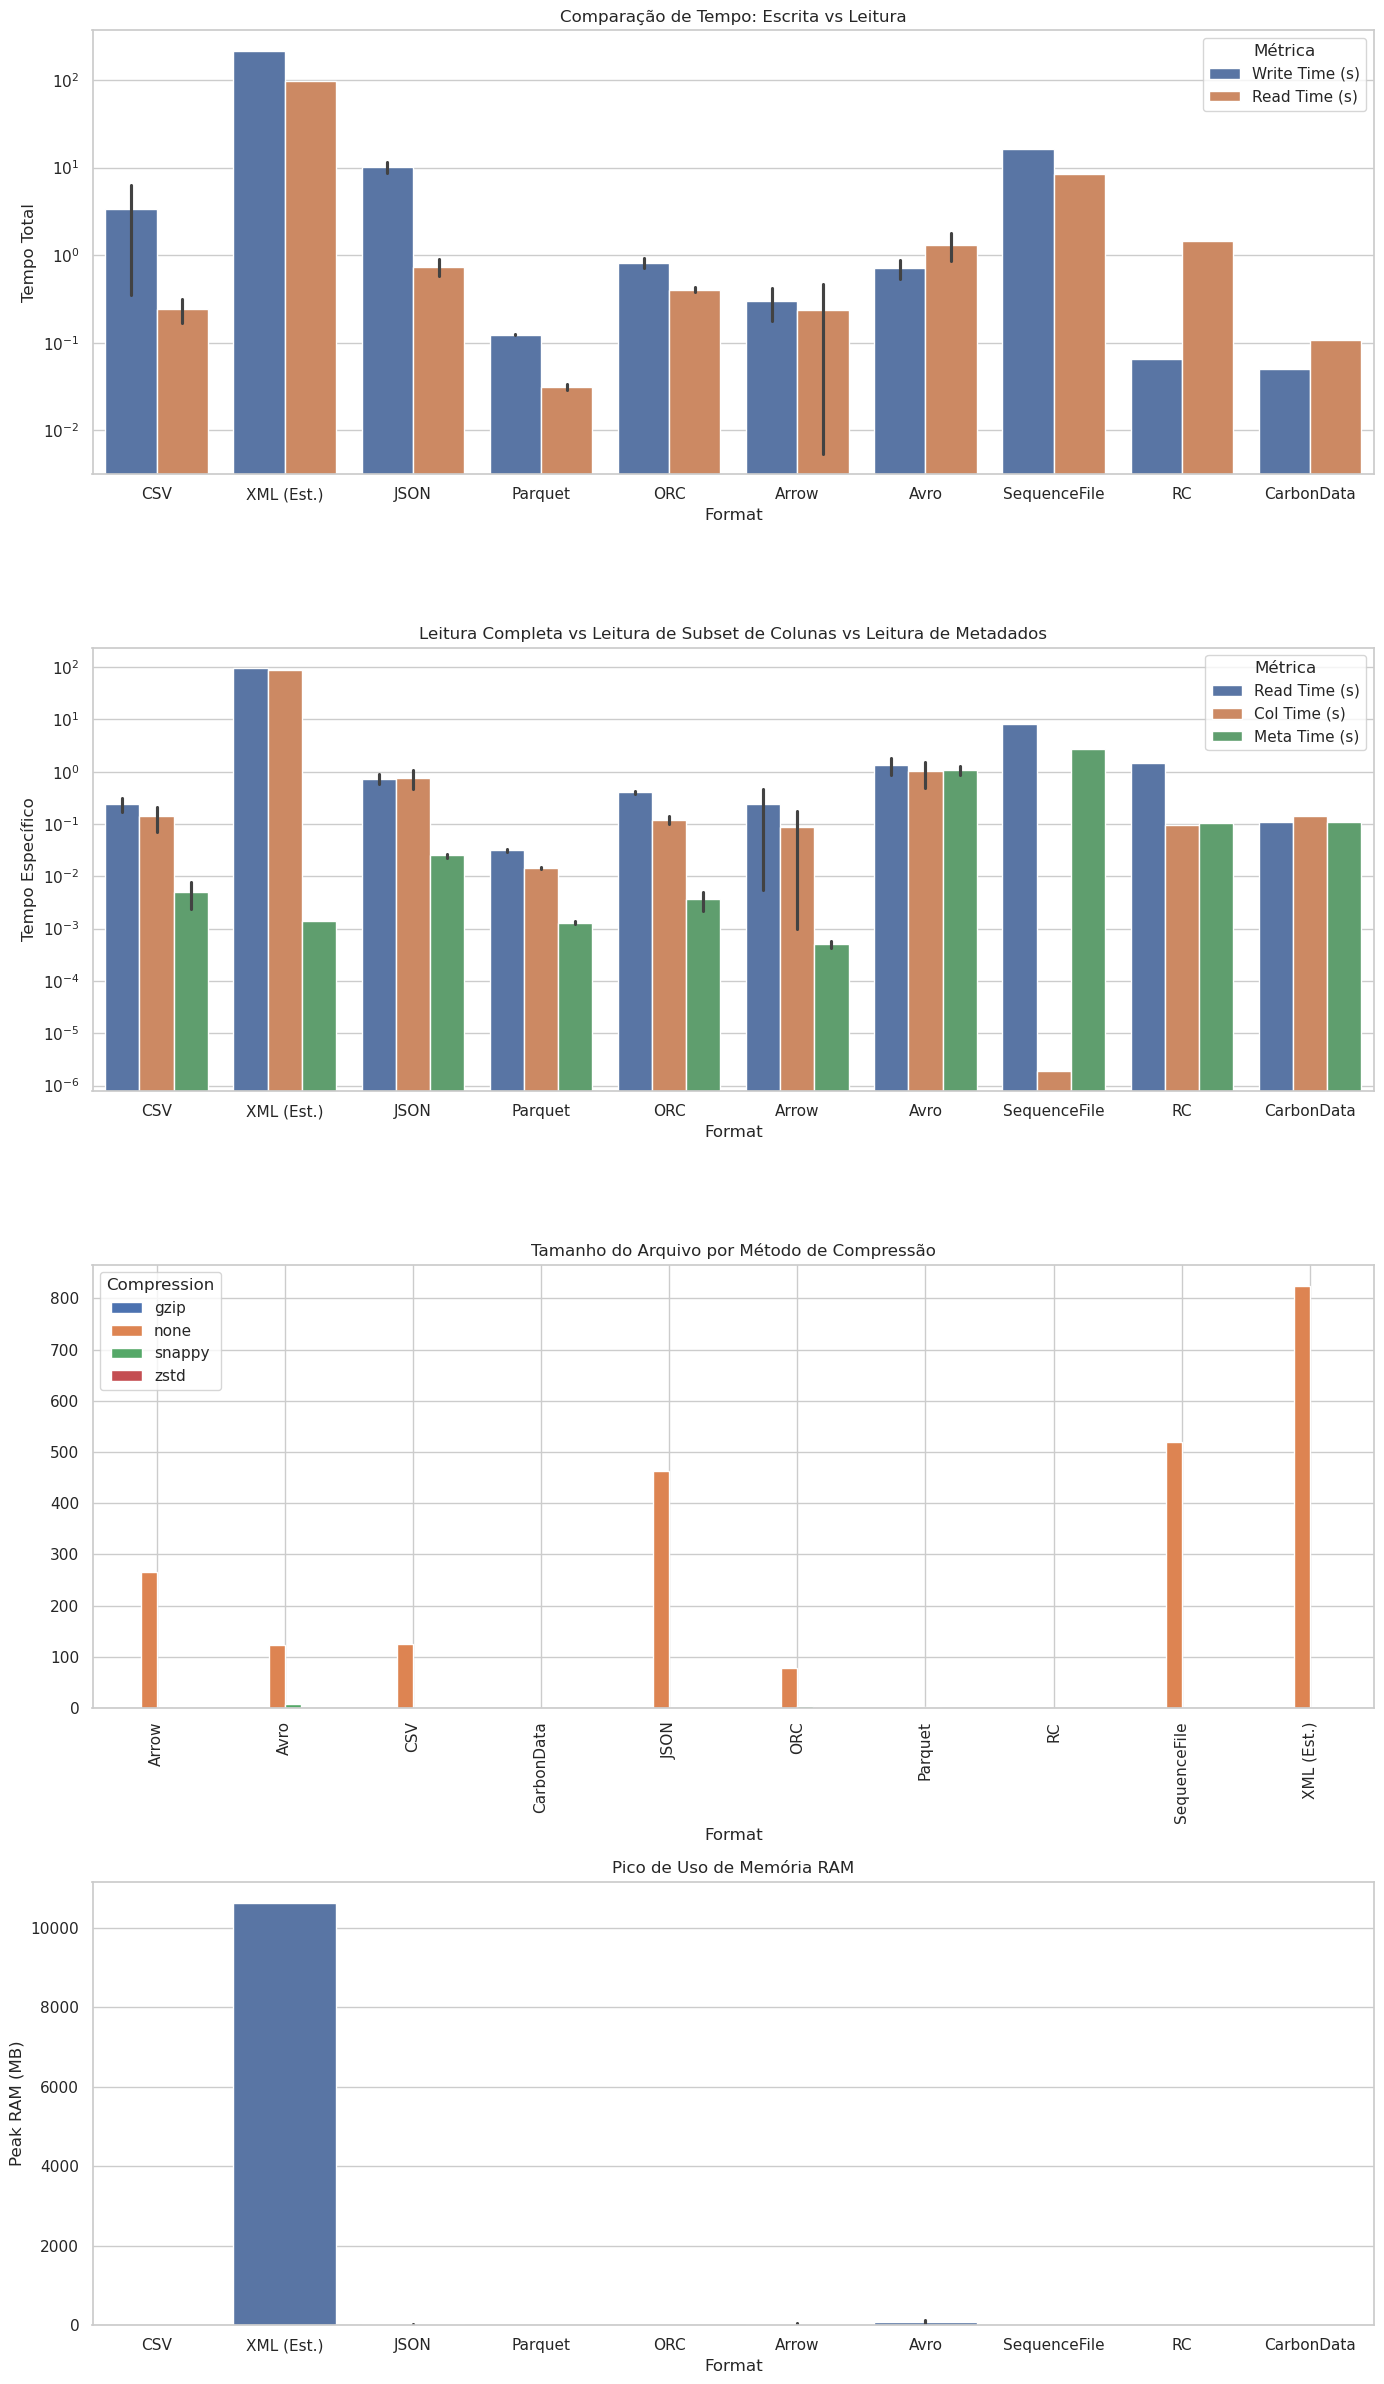

**Tempo Total de Processamento: 135.81s**


In [11]:
df_final = pd.DataFrame(results)
display(df_final)

# Estendendo a visualização para incluir os novos Tempos de Metadados e de Coluna
fig, axes = plt.subplots(4, 1, figsize=(14, 24))

# Gráfico de Comparação Básica: Escrita vs Leitura
metrics_df = df_final.melt(id_vars=['Format', 'Compression'], value_vars=['Write Time (s)',
                                                                           'Read Time (s)'], var_name='Métrica', value_name='Tempo Total')
sns.barplot(data=metrics_df, x='Format', y='Tempo Total', hue='Métrica', ax=axes[0])
axes[0].set_title('Comparação de Tempo: Escrita vs Leitura')
axes[0].set_yscale('log') # Melhor visibilidade para diferentes escalas de tempo

# Gráfico de Comparação de Especificidade de Leitura
read_metrics = df_final.melt(id_vars=['Format', 'Compression'], value_vars=['Read Time (s)', 'Col Time (s)',
                                                                             'Meta Time (s)'], var_name='Métrica', value_name='Tempo Específico')
sns.barplot(data=read_metrics, x='Format', y='Tempo Específico', hue='Métrica', ax=axes[1])
axes[1].set_title('Leitura Completa vs Leitura de Subset de Colunas vs Leitura de Metadados')
axes[1].set_yscale('log')

# Gráfico de Comparação de Tamanho de Arquivo
df_final.pivot(index='Format', columns='Compression', values='Size (MB)').plot(kind='bar', ax=axes[2])
axes[2].set_title('Tamanho do Arquivo por Método de Compressão')

# Gráfico de Uso de Memória
sns.barplot(data=df_final, x='Format', y='Peak RAM (MB)', ax=axes[3])
axes[3].set_title('Pico de Uso de Memória RAM')

plt.tight_layout()
plt.show()

print(f"**Tempo Total de Processamento: {time.time() - workflow_start:.2f}s**")
